#### Imports

In [43]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

#### Load Dataset

In [44]:
df = pd.read_csv(
    "../data\\cleaned_ai_stocks_task1.csv"
)

df["Date"] = pd.to_datetime(df["Date"])

print(df.shape)

df.head()

(2109, 53)


,Date,AMD_Close,MSFT_Close,NVDA_Close,^IXIC_Close,AMD_High,MSFT_High,NVDA_High,^IXIC_High,AMD_Low,...,NVDA_Return_Capped,NVDA_Volume_Capped,^IXIC_Return,^IXIC_LogReturn,^IXIC_NormClose,^IXIC_MA20,^IXIC_MA50,^IXIC_Volatility20,^IXIC_Return_Capped,^IXIC_Volume_Capped
0,2018-01-02,10.98,78.699905,4.928265,7006.899902,11.02,79.029539,4.931973,7006.910156,10.34,...,NaN,355616000,NaN,NaN,100.000000,NaN,NaN,NaN,NaN,1929700000
1,2018-01-03,11.55,79.066162,5.252614,7065.529785,12.14,79.212669,5.283022,7069.149902,11.36,...,0.065814,914704000,0.008367,0.008333,100.836745,NaN,NaN,NaN,0.008367,2173130000
2,2018-01-04,12.12,79.762062,5.280303,7077.910156,12.43,80.265671,5.390561,7098.049805,11.97,...,0.005271,583268000,0.001752,0.001751,101.013433,NaN,NaN,NaN,0.001752,2103220000
3,2018-01-05,11.88,80.750946,5.325050,7136.560059,12.22,80.952390,5.362380,7137.040039,11.66,...,0.008474,580124000,0.008286,0.008252,101.850464,NaN,NaN,NaN,0.008286,2024000000
4,2018-01-08,12.28,80.833359,5.488214,7157.390137,12.30,81.108056,5.562378,7161.350098,11.85,...,0.030641,881216000,0.002919,0.002915,102.147743,NaN,NaN,NaN,0.002919,2055010000


#### Business Problem Statemet

In [45]:
print("""
BUSINESS PROBLEM

The rise of Artificial Intelligence has
significantly impacted technology stocks.

This project investigates:

1. Which company benefited most?
2. Which company carried the highest risk?
3. How strongly do these stocks move
   with the broader market?
4. Can stock movement be predicted
   using historical market indicators?
""")


BUSINESS PROBLEM

The rise of Artificial Intelligence has
significantly impacted technology stocks.

This project investigates:

1. Which company benefited most?
2. Which company carried the highest risk?
3. How strongly do these stocks move
   with the broader market?
4. Can stock movement be predicted
   using historical market indicators?



#### Executive Summary Table

In [46]:
summary = pd.DataFrame({

    "Stock":[
        "NVIDIA",
        "Microsoft",
        "AMD",
        "NASDAQ"
    ],

    "Latest Close":[

        df["NVDA_Close"].iloc[-1],
        df["MSFT_Close"].iloc[-1],
        df["AMD_Close"].iloc[-1],
        df["^IXIC_Close"].iloc[-1]
    ]
})

summary

,Stock,Latest Close
0,NVIDIA,215.330002
1,Microsoft,418.570007
2,AMD,467.510010
3,NASDAQ,26343.970703


#### Long-Term Growth Analysis

In [47]:
growth_df = pd.DataFrame()

growth_df["Date"] = df["Date"]

for stock in [
    "NVDA",
    "MSFT",
    "AMD",
    "^IXIC"
]:

    growth_df[stock] = (
        df[f"{stock}_Close"] /
        df[f"{stock}_Close"].iloc[0]
    ) * 100

growth_df.head()

,Date,NVDA,MSFT,AMD,^IXIC
0,2018-01-02,100.000000,100.000000,100.000000,100.000000
1,2018-01-03,106.581422,100.465384,105.191263,100.836745
2,2018-01-04,107.143243,101.349629,110.382517,101.013433
3,2018-01-05,108.051226,102.606154,108.196727,101.850464
4,2018-01-08,111.361990,102.710872,111.839711,102.147743


#### Growth Visualization

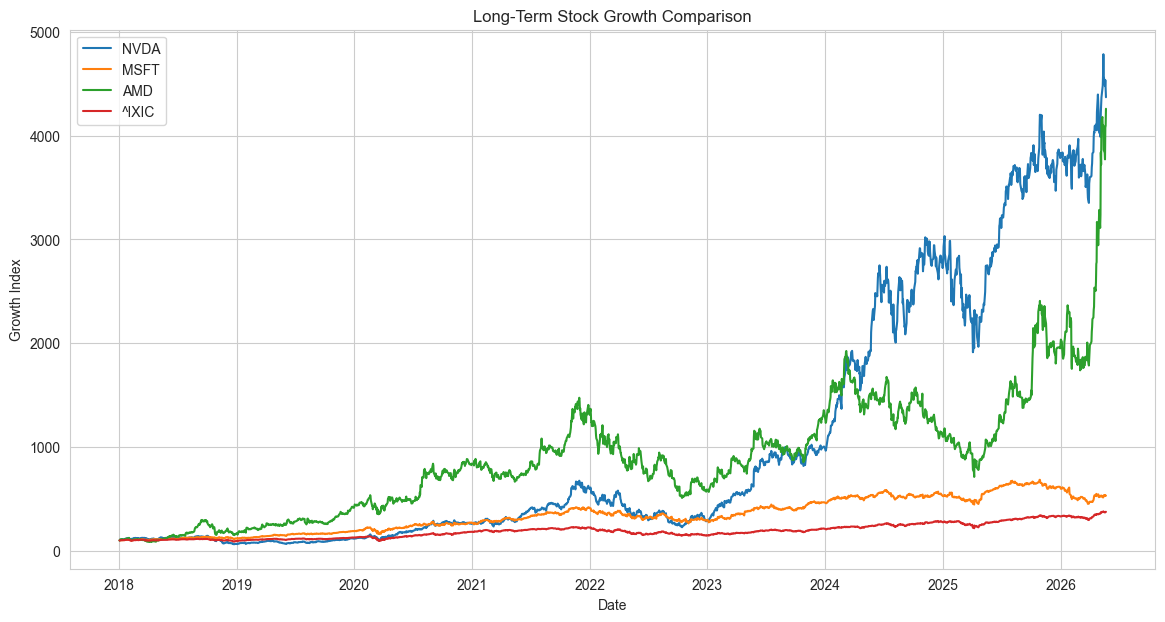

In [48]:
plt.figure(figsize=(14,7))

for stock in [
    "NVDA",
    "MSFT",
    "AMD",
    "^IXIC"
]:
    plt.plot(
        growth_df["Date"],
        growth_df[stock],
        label=stock
    )

plt.title(
    "Long-Term Stock Growth Comparison"
)

plt.ylabel("Growth Index")

plt.xlabel("Date")

plt.legend()

plt.show()

#### Calculate Investment Returns

Business scenario:
**What if an investor invested $10,000?**

In [49]:
investment = 10000

results = []

for stock in [
    "NVDA",
    "MSFT",
    "AMD",
    "^IXIC"
]:

    start_price = df[f"{stock}_Close"].iloc[0]
    end_price = df[f"{stock}_Close"].iloc[-1]

    final_value = (
        investment *
        end_price /
        start_price
    )

    results.append(
        [stock, final_value]
    )

investment_df = pd.DataFrame(
    results,
    columns=[
        "Stock",
        "Final Portfolio Value"
    ]
)

investment_df

,Stock,Final Portfolio Value
0,NVDA,436928.652427
1,MSFT,53185.579477
2,AMD,425783.268904
3,^IXIC,37597.184304


#### Investment Outcome Visualization

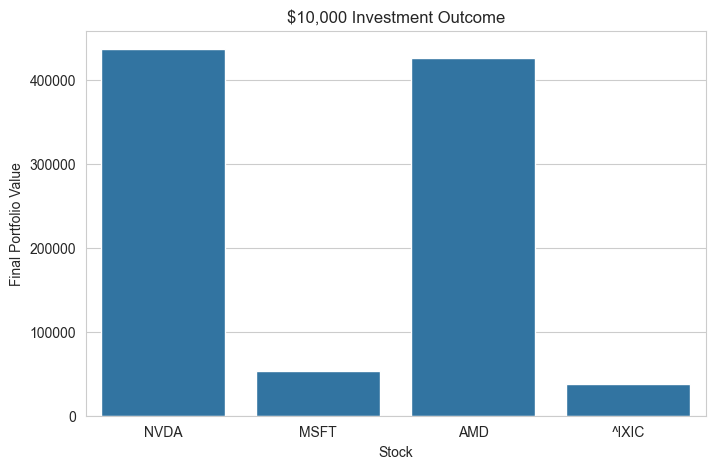

In [50]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=investment_df,
    x="Stock",
    y="Final Portfolio Value"
)

plt.title(
    "$10,000 Investment Outcome"
)

plt.show()

#### Risk Analysis

In [51]:
risk_df = pd.DataFrame({

    "Stock":[
        "NVDA",
        "MSFT",
        "AMD",
        "NASDAQ"
    ],

    "Risk":[

        df["NVDA_Return"].std(),

        df["MSFT_Return"].std(),

        df["AMD_Return"].std(),

        df["^IXIC_Return"].std()
    ]
})

risk_df

,Stock,Risk
0,NVDA,0.031942
1,MSFT,0.017959
2,AMD,0.035332
3,NASDAQ,0.014826


#### Risk Visualization

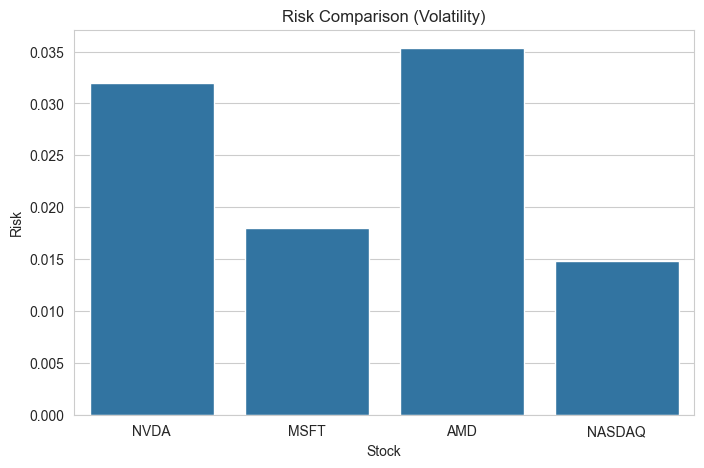

In [52]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=risk_df,
    x="Stock",
    y="Risk"
)

plt.title(
    "Risk Comparison (Volatility)"
)

plt.show()

#### Market Relationship Analysis

In [53]:
market_corr = pd.DataFrame({

    "Stock":[
        "NVDA",
        "MSFT",
        "AMD"
    ],

    "Correlation with NASDAQ":[

        df["NVDA_Return"].corr(
            df["^IXIC_Return"]
        ),

        df["MSFT_Return"].corr(
            df["^IXIC_Return"]
        ),

        df["AMD_Return"].corr(
            df["^IXIC_Return"]
        )
    ]
})

market_corr

,Stock,Correlation with NASDAQ
0,NVDA,0.785269
1,MSFT,0.836851
2,AMD,0.669680


#### Correlation Visualization

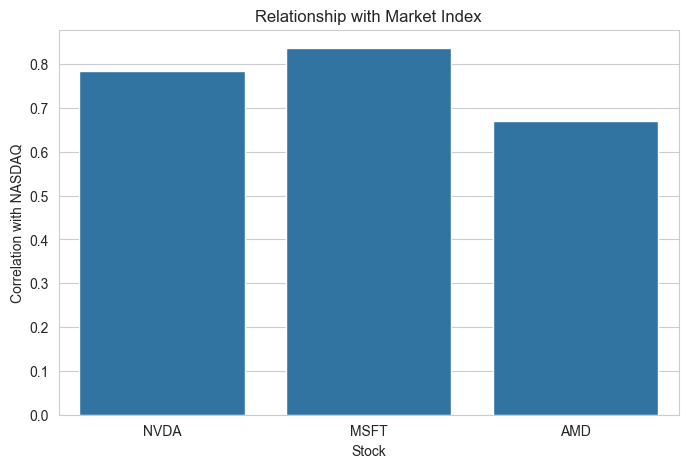

In [54]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=market_corr,
    x="Stock",
    y="Correlation with NASDAQ"
)

plt.title(
    "Relationship with Market Index"
)

plt.show()

#### AI Boom Impact Analysis

In [55]:
ai_event = pd.Timestamp(
    "2022-11-30"
)

pre_ai = df[
    df["Date"] < ai_event
]

post_ai = df[
    df["Date"] >= ai_event
]

print(
    pre_ai.shape,
    post_ai.shape
)

(1237, 53) (872, 53)


#### AI Era Performance

In [56]:
ai_results = []

for stock in [
    "NVDA",
    "MSFT",
    "AMD"
]:

    before = (
        (
            pre_ai[f"{stock}_Close"].iloc[-1]
            -
            pre_ai[f"{stock}_Close"].iloc[0]
        )
        /
        pre_ai[f"{stock}_Close"].iloc[0]
    ) * 100

    after = (
        (
            post_ai[f"{stock}_Close"].iloc[-1]
            -
            post_ai[f"{stock}_Close"].iloc[0]
        )
        /
        post_ai[f"{stock}_Close"].iloc[0]
    ) * 100

    ai_results.append(
        [stock, before, after]
    )

ai_df = pd.DataFrame(
    ai_results,
    columns=[
        "Stock",
        "Pre AI %",
        "Post AI %"
    ]
)

ai_df

,Stock,Pre AI %,Post AI %
0,NVDA,216.917231,1173.753189
1,MSFT,196.922219,68.725471
2,AMD,568.397108,502.228554


#### AI Impact Visualization

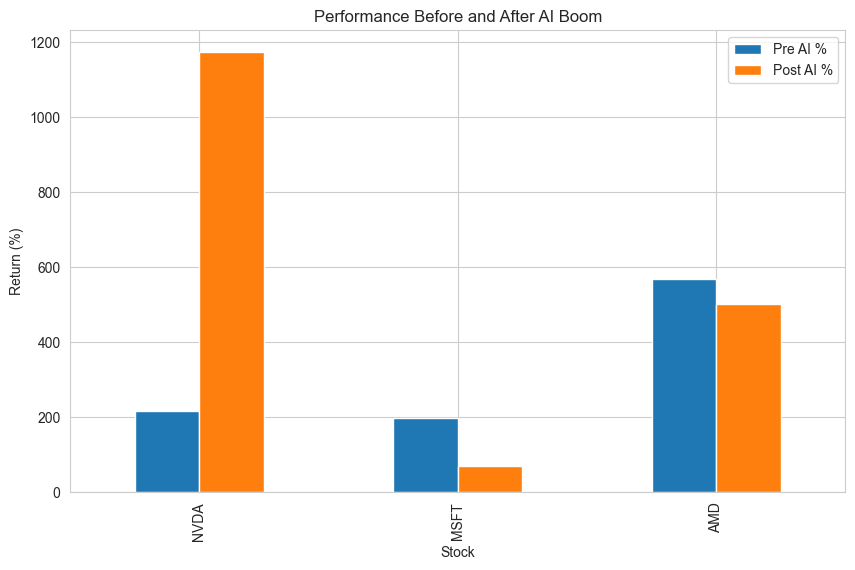

In [57]:
ai_df.set_index(
    "Stock"
)[
    ["Pre AI %", "Post AI %"]
].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Performance Before and After AI Boom"
)

plt.ylabel(
    "Return (%)"
)

plt.show()

#### Real-World Prediction

In [58]:
df["Target"] = (
    df["NVDA_Close"].shift(-1)
    >
    df["NVDA_Close"]
).astype(int)

features = [

    "NVDA_Close",
    "NVDA_Return",
    "NVDA_MA20",
    "NVDA_MA50",

    "MSFT_Return",
    "AMD_Return",

    "^IXIC_Return"
]

model_df = df[
    features + ["Target"]
].dropna()

#### Train Prediction Model

In [59]:
X = model_df[features]
y = model_df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

preds = model.predict(
    X_test
)

accuracy = accuracy_score(
    y_test,
    preds
)

print(
    "Prediction Accuracy:",
    round(accuracy,4)
)

Prediction Accuracy: 0.4951


#### Business Recommendation Table

In [60]:
recommendation = pd.DataFrame({

    "Category":[

        "Highest Growth",

        "Lowest Risk",

        "Best Market Alignment"
    ],

    "Result":[

        investment_df.sort_values(
            "Final Portfolio Value",
            ascending=False
        ).iloc[0]["Stock"],

        risk_df.sort_values(
            "Risk"
        ).iloc[0]["Stock"],

        market_corr.sort_values(
            "Correlation with NASDAQ",
            ascending=False
        ).iloc[0]["Stock"]
    ]
})

recommendation

,Category,Result
0,Highest Growth,NVDA
1,Lowest Risk,NASDAQ
2,Best Market Alignment,MSFT


#### Executive Findings

In [61]:
print("""
EXECUTIVE FINDINGS

1. Compare growth of major AI-linked stocks.
2. Measure investment performance.
3. Evaluate risk and volatility.
4. Examine correlation with the market.
5. Assess impact of AI expansion.
6. Demonstrate practical prediction capability.

This case study shows how
data science can support
financial decision making.
""")


EXECUTIVE FINDINGS

1. Compare growth of major AI-linked stocks.
2. Measure investment performance.
3. Evaluate risk and volatility.
4. Examine correlation with the market.
5. Assess impact of AI expansion.
6. Demonstrate practical prediction capability.

This case study shows how
data science can support
financial decision making.



#### Save Final Outputs

In [62]:
investment_df.to_csv(
    "../reports/project/final_investment_analysis.csv",
    index=False
)

risk_df.to_csv(
    "../reports/project/final_risk_analysis.csv",
    index=False
)

market_corr.to_csv(
    "../reports/project/final_market_correlation.csv",
    index=False
)

recommendation.to_csv(
    "../reports/project/final_business_recommendations.csv",
    index=False
)

print("Task 4 outputs saved.")

Task 4 outputs saved.


In [63]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import numpy as np

# Try the strongest tree-based candidates and keep the one that generalizes best.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

candidate_searches = {
    "Decision Tree": (
        DecisionTreeClassifier(random_state=42),
        {
            "max_depth": [None, 3, 5, 7, 9, 12, 15],
            "min_samples_split": [2, 4, 6, 8, 10],
            "min_samples_leaf": [1, 2, 4, 6, 8],
            "max_features": [None, "sqrt", "log2"],
            "class_weight": [None, "balanced"],
        },
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=42, n_jobs=-1),
        {
            "n_estimators": [200, 400, 600, 800],
            "max_depth": [None, 5, 8, 12, 16],
            "min_samples_split": [2, 4, 6, 8, 10],
            "min_samples_leaf": [1, 2, 4, 6],
            "max_features": ["sqrt", "log2", 0.5],
            "class_weight": [None, "balanced", "balanced_subsample"],
        },
    ),
}

best_name = None
best_search = None
best_cv_score = -1.0

for name, (estimator, param_grid) in candidate_searches.items():
    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_grid,
        n_iter=12,
        scoring="accuracy",
        cv=cv,
        random_state=42,
        n_jobs=-1,
    )
    search.fit(X_train, y_train)
    if search.best_score_ > best_cv_score:
        best_name = name
        best_search = search
        best_cv_score = search.best_score_

best_model = best_search.best_estimator_

# Tune the probability threshold on out-of-fold training predictions.
oof_proba = cross_val_predict(
    best_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

threshold_grid = np.linspace(0.30, 0.70, 81)
best_threshold = 0.5
best_oof_accuracy = -1.0

for threshold in threshold_grid:
    oof_preds = (oof_proba >= threshold).astype(int)
    oof_accuracy = accuracy_score(y_train, oof_preds)
    if oof_accuracy > best_oof_accuracy:
        best_oof_accuracy = oof_accuracy
        best_threshold = threshold

best_model.fit(X_train, y_train)
test_proba = best_model.predict_proba(X_test)[:, 1]
preds = (test_proba >= best_threshold).astype(int)
accuracy = accuracy_score(y_test, preds)

baseline_accuracy = accuracy_score(y_test, model.predict(X_test))

print(f"Best model: {best_name}")
print(f"Best CV accuracy: {best_cv_score:.4f}")
print(f"Chosen threshold: {best_threshold:.2f}")
print(f"Baseline test accuracy: {baseline_accuracy:.4f}")
print(f"Tuned test accuracy: {accuracy:.4f}")
print(classification_report(y_test, preds))
print(f"ROC AUC: {roc_auc_score(y_test, test_proba):.4f}")

model = best_model


c:\Users\karbi\miniconda3\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best model: Random Forest
Best CV accuracy: 0.5407
Chosen threshold: 0.45
Baseline test accuracy: 0.4951
Tuned test accuracy: 0.5146
              precision    recall  f1-score   support

           0       0.53      0.05      0.09       201
           1       0.51      0.96      0.67       211

    accuracy                           0.51       412
   macro avg       0.52      0.50      0.38       412
weighted avg       0.52      0.51      0.39       412

ROC AUC: 0.5067
